In [1]:
from google.colab import drive
drive.mount('/content/drive')

my_path="/content/drive/MyDrive/CS491NLP/Data/"

Mounted at /content/drive


In [2]:
!pip install datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.4 MB/s eta 0:00:00


# Load dataset from Hugging Face

In [4]:
from datasets import load_dataset
import random

# Load the dataset
dataset = load_dataset("Open-Orca/OpenOrca",split='train').shuffle(seed=42)

#Take a random 3000 entries
random_subset= dataset.select(range(3000))

#Get the 'instruction' field from the random subset
docs=random_subset['question']


# Train Top2Vec model. Also save and load.

In [5]:
!pip install top2vec -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 51.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.4 MB/s eta 0:00:00


In [6]:
##If model is already trained and saved (see section below) then this can be skipped!!
from top2vec import Top2Vec

# Assuming 'docs' is a list of text documents you wish to model
model = Top2Vec(docs, embedding_model='doc2vec', speed='deep-learn')
#fast-learn, learn, deep-learn

2024-04-01 03:15:12,162 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2024-04-01 03:15:13,472 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2024-04-01 03:21:33,028 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2024-04-01 03:21:56,749 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2024-04-01 03:21:56,855 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


In [ ]:
# Load model
import pickle

with open(my_path+'prompt_deep_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Topic modeling

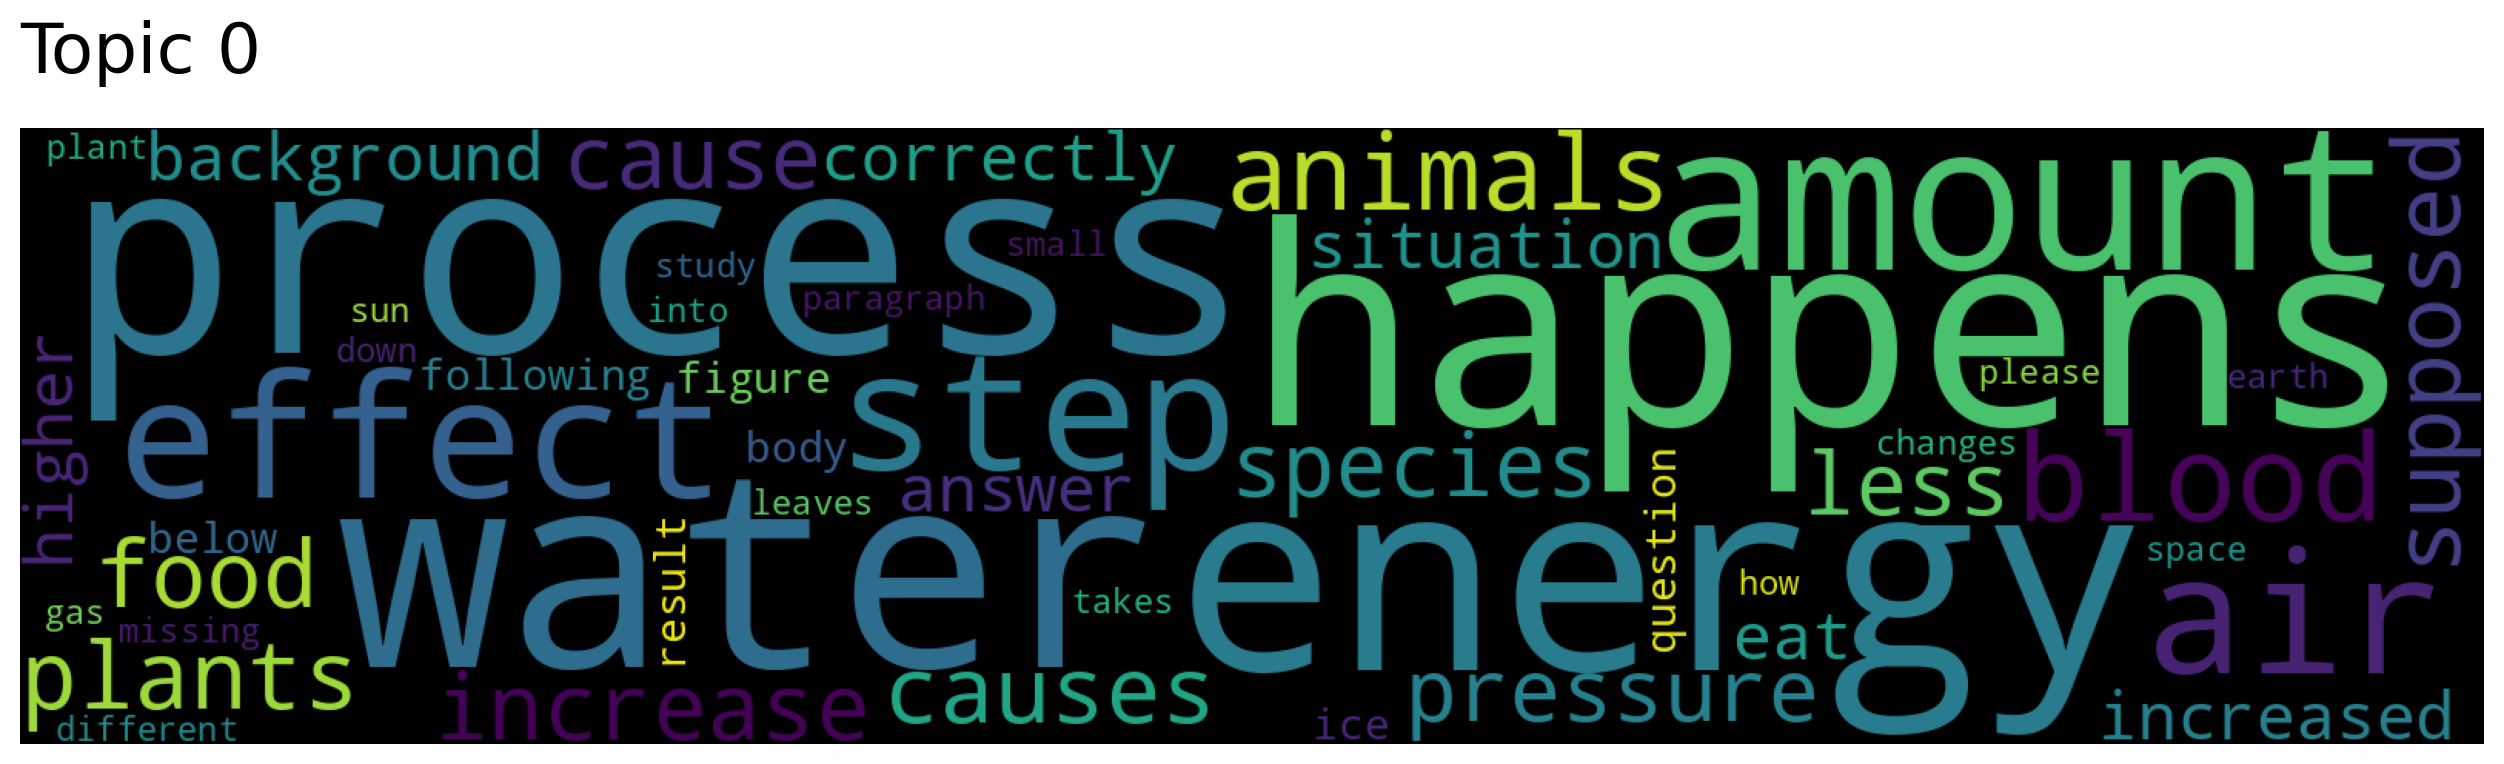

In [11]:
model.generate_topic_wordcloud(0)

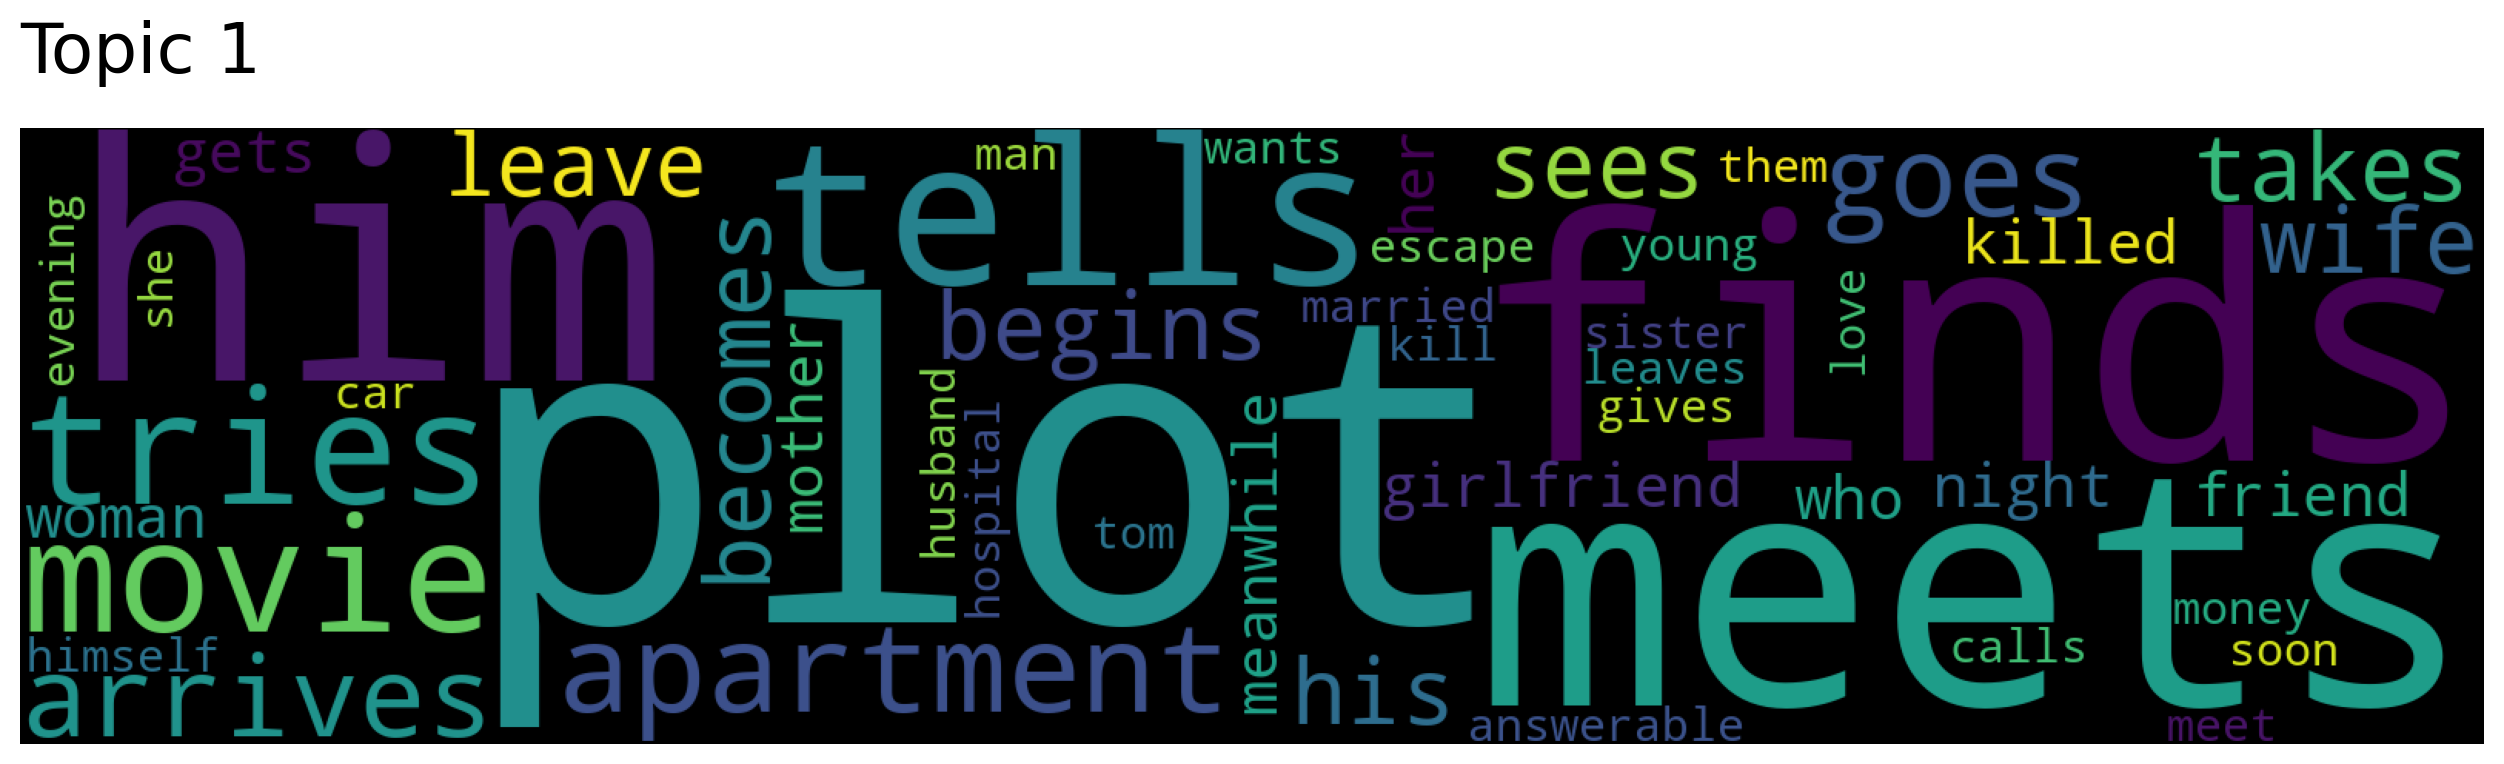

In [10]:
model.generate_topic_wordcloud(1)

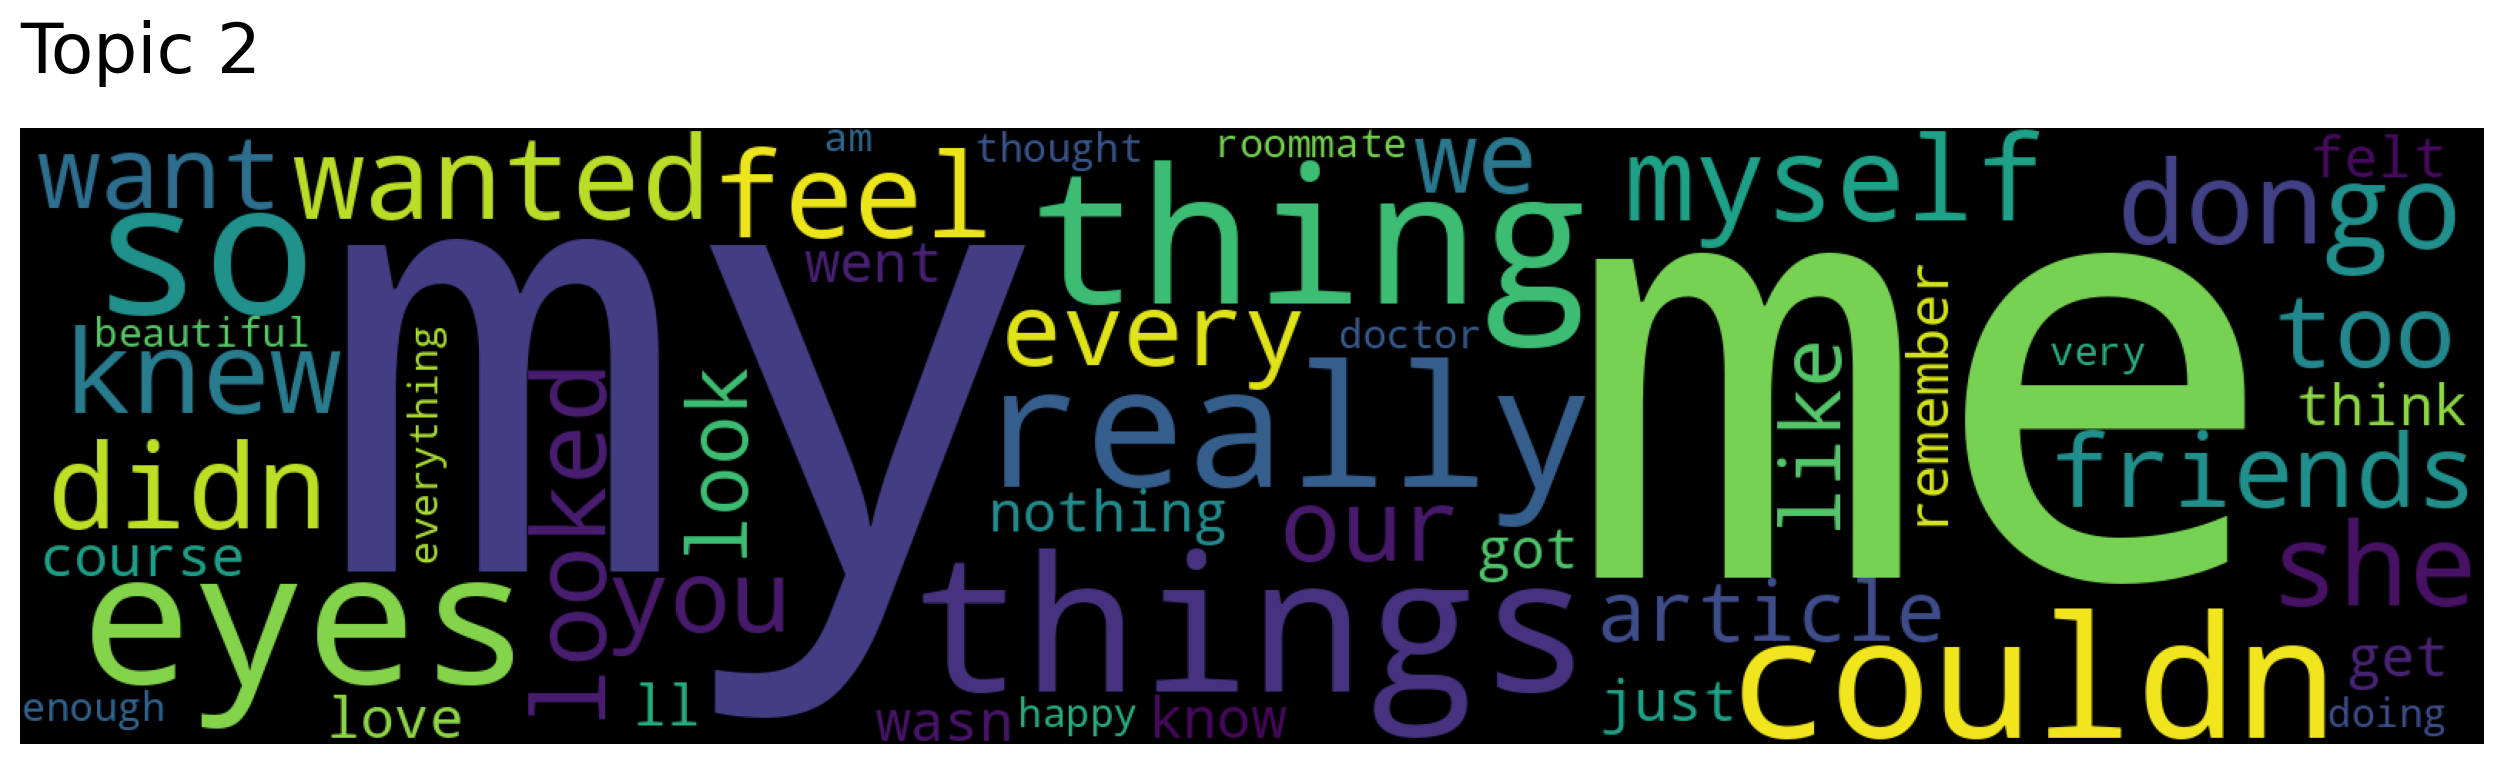

In [12]:
model.generate_topic_wordcloud(2)

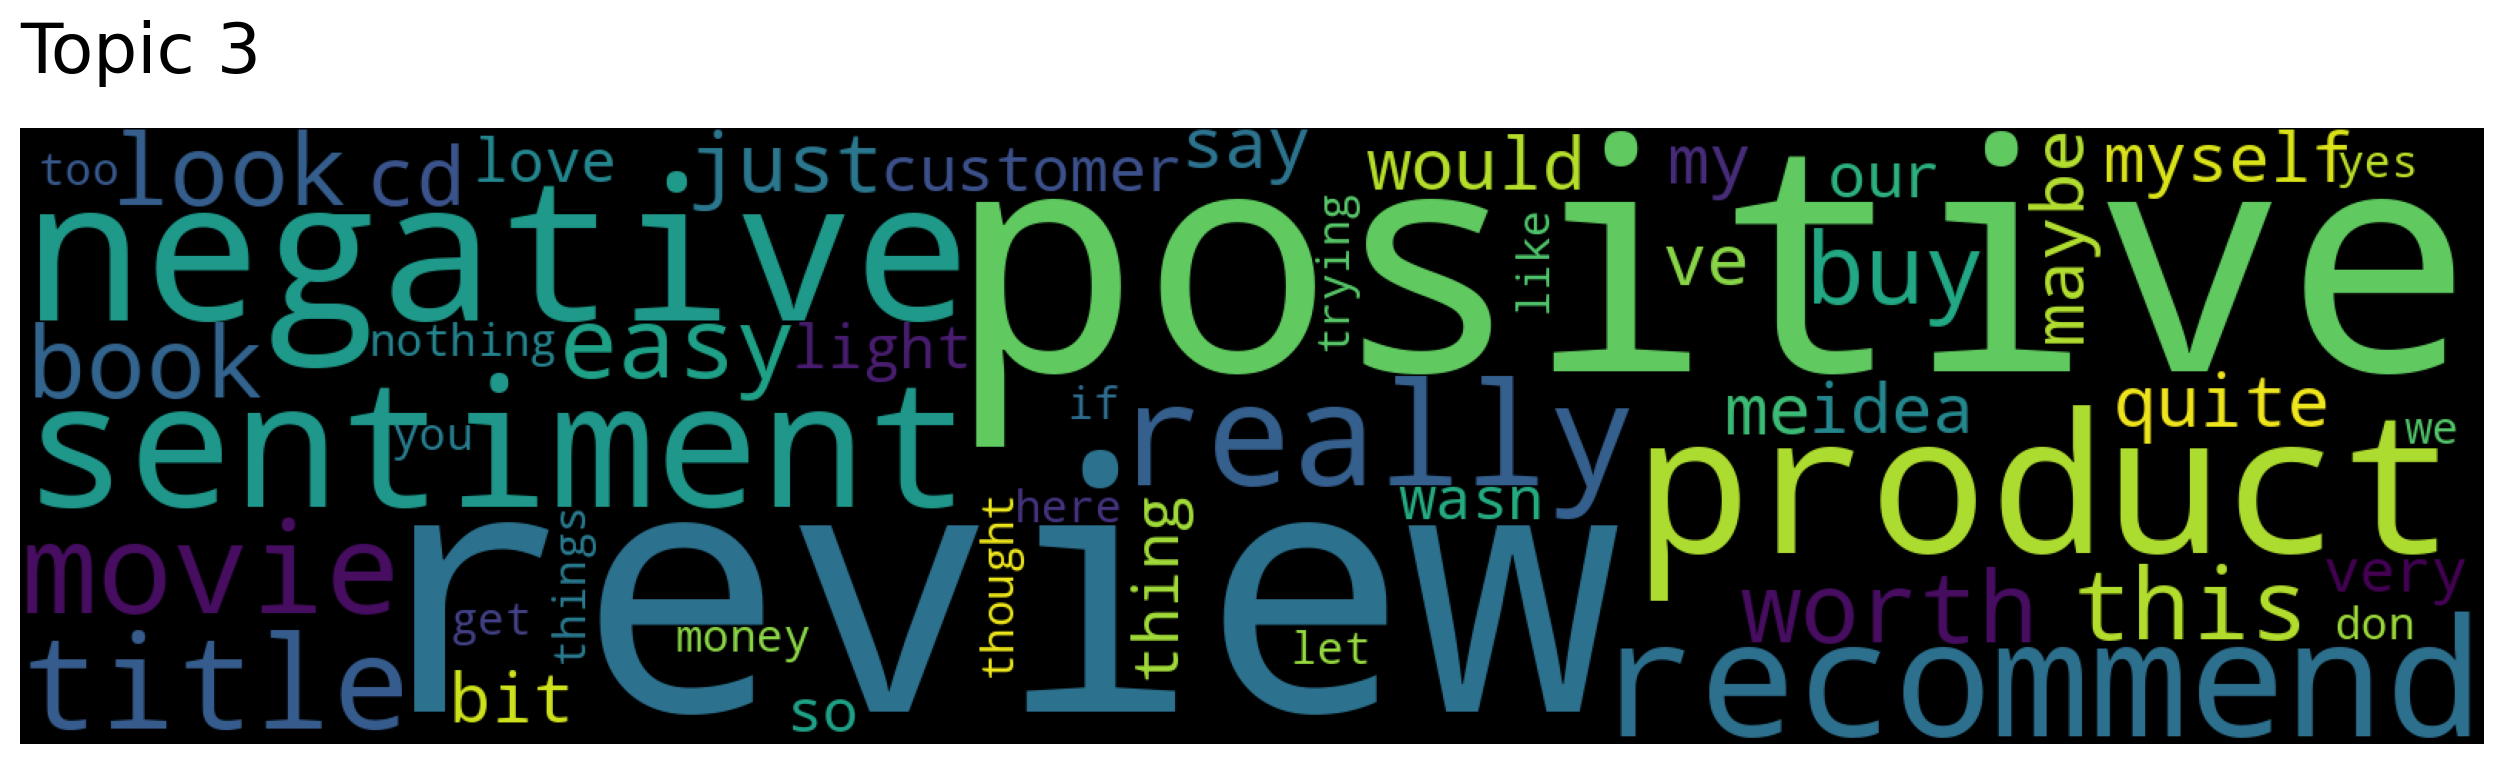

In [13]:
model.generate_topic_wordcloud(3)

Topic0: 'process', 'happens', 'water','energy';
Topic1: 'plot', 'finds', 'him', 'meets';
Topic2: 'my', 'me';
Topic3: 'review', 'positive', 'negative'.